### Lecture 6 - Finger exercise 3: Practical Implementation of LSTM in PyTorch
Let’s look at a real example of Starbucks’ stock market price, which is an example of Sequential Data. In this example we will go over a simple LSTM model using Python and PyTorch to predict the Volume of Starbucks’ stock price.

Let’s load the dataset first. You can download the dataset from [this](https://query1.finance.yahoo.com/v7/finance/download/SBUX?period1=1576063151&period2=1607685551&interval=1d&events=history&includeAdjustedClose=true) link. You can load it using pandas.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('SBUX.csv', index_col = 'Date', parse_dates=True)

You can check the head of the dataset via

In [2]:
df.head(5)

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2019-12-11,86.260002,86.870003,85.849998,86.589996,83.039520,4921900
2019-12-12,88.000000,88.889999,87.540001,88.209999,84.593086,10282100
2019-12-13,88.019997,88.790001,87.580002,88.669998,85.034225,6714100
2019-12-16,89.139999,89.300003,88.430000,88.779999,85.139717,6705600
2019-12-17,88.870003,88.970001,87.470001,88.129997,84.516365,7296900


Now, you can plot the label column, with the timeframe to check the original trend of the volume of stock.

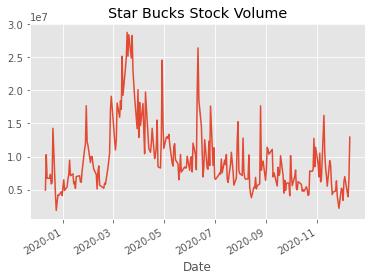

In [3]:
plt.style.use('ggplot')
df['Volume'].plot(label='CLOSE', title='Star Bucks Stock Volume')

Since this notbook is more focused on the PyTorch part, we won’t dive in to further data exploration and simply dive in on how to build the LSTM model. Before making the model, one last thing you have to do is to prepare the data for the model. This is also known as data-preprocessing. 

Let’s get the data and the labels separate from a single dataframe.

In [4]:
X = df.iloc[:, :-1]
y = df.iloc[:, 5:6] 

Since this is not an article focused on different techniques of data preprocessing, you will use StandardScaler for the features, and MinMaxScaler (to scale values between 0 and 1) for the output values. Notice that it is a regression problem, so it is very beneficial to scale your outputs otherwise you will be dealing with a huge loss.

In [5]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
mm = MinMaxScaler()
ss = StandardScaler()


X_ss = ss.fit_transform(X)
y_mm = mm.fit_transform(y) 

This will transform and scale the dataset. The next thing is splitting the dataset into 2 parts. 1 is for the training, and the other part is for testing the values. Since it is sequential data, and order is important,  you will take the first 200 rows for training, and 53 for testing the data. You will notice that you can make a really good prediction on such a low amount of data using LSTMs.

In [6]:
#first 200 for training

X_train = X_ss[:200, :]
X_test = X_ss[200:, :]

y_train = y_mm[:200, :]
y_test = y_mm[200:, :] 

Next, you can print out the training and testing data shapes for the confirmation.

In [7]:
print("Training Shape", X_train.shape, y_train.shape)
print("Testing Shape", X_test.shape, y_test.shape) 

Training Shape (200, 5) (200, 1)
Testing Shape (53, 5) (53, 1)


If you are programming in PyTorch for a while, you should know that in PyTorch, all you deal with are tensors, which you can think of as a powerful version of numpy. So you have to convert the dataset into tensors.

Let’s import important libraries first.

In [8]:
import torch #pytorch
import torch.nn as nn
from torch.autograd import Variable 

You can simply convert the Numpy Arrays to Tensors and to Variables (which can be differentiated) via this simple code.

In [9]:
X_train_tensors = Variable(torch.Tensor(X_train))
X_test_tensors = Variable(torch.Tensor(X_test))

y_train_tensors = Variable(torch.Tensor(y_train))
y_test_tensors = Variable(torch.Tensor(y_test)) 

Now the next step is to check the input format of an LSTM. This means that since LSTM is specially built for sequential data, it can not take in simple 2-D data as input. They need to have the timestamp information with them too, as we discussed that we need to have input at each timestamp. So let’s convert the dataset.

In [10]:
#reshaping to rows, timestamps, features

X_train_tensors_final = torch.reshape(X_train_tensors,   (X_train_tensors.shape[0], 1, X_train_tensors.shape[1]))


X_test_tensors_final = torch.reshape(X_test_tensors,  (X_test_tensors.shape[0], 1, X_test_tensors.shape[1])) 

Now you can confirm the shape of the dataset via printing the shapes.


In [11]:
print("Training Shape", X_train_tensors_final.shape, y_train_tensors.shape)
print("Testing Shape", X_test_tensors_final.shape, y_test_tensors.shape) 

Training Shape torch.Size([200, 1, 5]) torch.Size([200, 1])
Testing Shape torch.Size([53, 1, 5]) torch.Size([53, 1])


Now, you are good to go, and it’s time to build the LSTM model. Since PyTorch is way more pythonic, every model in it needs to be inherited from nn.Module superclass. 

Here you’ve defined all the important variables, and layers. Next you are going to use 2 LSTM layers with the same hyperparameters stacked over each other (via hidden_size), you have defined the 2 Fully Connected layers, the ReLU layer, and some helper variables. Next, you are going to define the forward pass of the LSTM.

In [12]:
class LSTM1(nn.Module):
    def __init__(self, num_classes, input_size, hidden_size, num_layers, seq_length):
        super(LSTM1, self).__init__()
        self.num_classes = num_classes #number of classes
        self.num_layers = num_layers #number of layers
        self.input_size = input_size #input size
        self.hidden_size = hidden_size #hidden state
        self.seq_length = seq_length #sequence length

        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                          num_layers=num_layers, batch_first=True) #lstm
        self.fc_1 =  nn.Linear(hidden_size, 128) #fully connected 1
        self.fc = nn.Linear(128, num_classes) #fully connected last layer

        self.relu = nn.ReLU()
    
    def forward(self,x):
        h_0 = Variable(torch.zeros(self.num_layers, x.size(0), self.hidden_size)) #hidden state
        c_0 = Variable(torch.zeros(self.num_layers, x.size(0), self.hidden_size)) #internal state
        # Propagate input through LSTM
        output, (hn, cn) = self.lstm(x, (h_0, c_0)) #lstm with input, hidden, and internal state
        hn = hn.view(-1, self.hidden_size) #reshaping the data for Dense layer next
        out = self.relu(hn)
        out = self.fc_1(out) #first Dense
        out = self.relu(out) #relu
        out = self.fc(out) #Final Output
        return out

Here you have defined the hidden state, and internal state first, initialized with zeros. First of all, you are going to pass the hidden state and internal state in LSTM, along with the input at the current timestamp t. This will return a new hidden state, current state, and output. You’ll reshape the output so that it can pass to a Dense Layer. Next, simply apply activations, and pass them to the dense layers, and return the output.

This completes the Forward Pass and the class LSTM1. You will apply backpropagation logic while training the model at runtime.

You can see the model statistics via printing the model.

Let’s define some important variables now, that you will use. These are hyperparameters, such as the number of epochs, hidden size, etc.

In [13]:
num_epochs = 1000 #1000 epochs
learning_rate = 0.001 #0.001 lr

input_size = 5 #number of features
hidden_size = 2 #number of features in hidden state
num_layers = 1 #number of stacked lstm layers

num_classes = 1 #number of output classes 

Now you will instantiate the class LSTM1 object.

In [14]:
lstm1 = LSTM1(num_classes, input_size, hidden_size, num_layers, X_train_tensors_final.shape[1]) #our lstm class 

Let’s define the Loss function and optimizer.

In [15]:
criterion = torch.nn.MSELoss()    # mean-squared error for regression
optimizer = torch.optim.Adam(lstm1.parameters(), lr=learning_rate) 

Now loop for the number of epochs, do the forward pass, calculate the loss, improve the weights via the optimizer step.# Train the model

In [16]:
for epoch in range(num_epochs):
  outputs = lstm1.forward(X_train_tensors_final) #forward pass
  optimizer.zero_grad() #caluclate the gradient, manually setting to 0
 
  # obtain the loss function
  loss = criterion(outputs, y_train_tensors)
 
  loss.backward() #calculates the loss of the loss function
 
  optimizer.step() #improve from loss, i.e backprop
  if epoch % 100 == 0:
    print("Epoch: %d, loss: %1.5f" % (epoch, loss.item())) 

Epoch: 0, loss: 0.17481
Epoch: 100, loss: 0.03850
Epoch: 200, loss: 0.02954
Epoch: 300, loss: 0.01664
Epoch: 400, loss: 0.01596
Epoch: 500, loss: 0.01424
Epoch: 600, loss: 0.01174
Epoch: 700, loss: 0.01113
Epoch: 800, loss: 0.01084
Epoch: 900, loss: 0.01067


This will start the training for 1000 epochs, and print the loss at every 100 epoch.

You can see that there is less loss, which means it is performing well. Let’s plot the predictions on the data set, to check out how it’s performing.

But before performing predictions on the whole dataset, you’ll need to bring the original dataset into the model suitable format, which can be done by using similar code as above.

In [17]:
df_X_ss = ss.transform(df.iloc[:, :-1]) #old transformers
df_y_mm = mm.transform(df.iloc[:, -1:]) #old transformers

df_X_ss = Variable(torch.Tensor(df_X_ss)) #converting to Tensors
df_y_mm = Variable(torch.Tensor(df_y_mm))
#reshaping the dataset
df_X_ss = torch.reshape(df_X_ss, (df_X_ss.shape[0], 1, df_X_ss.shape[1]))

You can now simply perform predictions on the whole dataset via a forward pass, and then to plot them, you will convert the predictions to numpy, reverse transform them (remember that you transformed the labels to check the actual answer, and that you’ll need to reverse transform it) and then plot it.

And you can see the predictions:

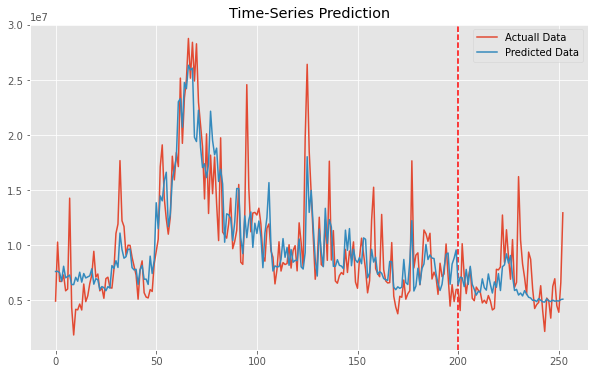

In [18]:
train_predict = lstm1(df_X_ss)#forward pass
data_predict = train_predict.data.numpy() #numpy conversion
dataY_plot = df_y_mm.data.numpy()

data_predict = mm.inverse_transform(data_predict) #reverse transformation
dataY_plot = mm.inverse_transform(dataY_plot)
plt.figure(figsize=(10,6)) #plotting
plt.axvline(x=200, c='r', linestyle='--') #size of the training set

plt.plot(dataY_plot, label='Actuall Data') #actual plot
plt.plot(data_predict, label='Predicted Data') #predicted plot
plt.title('Time-Series Prediction')
plt.legend()
plt.show() 